# Linear Regression & Optimization

**Scenario:**  
You are a junior data scientist at a marketing analytics firm. A consumer-goods client wants to know: _"How should we allocate our advertising budget across TV, Radio, and Newspaper to maximise sales?"_

You have data from **200 past campaigns**. Your goal: build a model that explains and predicts sales from advertising spend — and understand **every step** of how it works under the hood.

| Section | Topic |
|---|---|
| 1 | Dataset & Exploration |
| 2 | Simple Linear Regression — Theory |
| 3 | The Cost Function (MSE) |
| 4 | Gradient Descent from Scratch |
| 5 | Learning Rate — Too Small, Too Big, Just Right |
| 6 | Simple Linear Regression with sklearn |
| 7 | Multiple Linear Regression |
| 8 | Model Evaluation Metrics |
| 9 | Polynomial Regression & Overfitting |
| 10 | Cross-Validation & Learning Curves |
| 11 | Assumptions of Linear Regression |
| 12 | Summary |

---
## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (11, 5)
np.random.seed(42)

print('Libraries loaded.')

Libraries loaded.


---
## 1. Dataset & Exploration

We simulate 200 advertising campaigns. The **true** relationship (which we know because we generated the data):

$$\text{sales} = 5 + 0.05 \times \text{tv} + 0.18 \times \text{radio} + 0.005 \times \text{newspaper} + \varepsilon$$

- TV advertising has a **moderate** effect on sales
- Radio has the **strongest** effect per dollar
- Newspaper has a **negligible** effect
- $\varepsilon$ is random noise — representing things we cannot measure

Our model does **not** know this formula. It must learn it from the data.

In [2]:
N = 200

tv_budget        = np.random.uniform(0.7, 300, N)
radio_budget     = np.random.uniform(0.0,  50, N)
newspaper_budget = np.random.uniform(0.0, 114, N)

noise = np.random.normal(0, 2, N)

sales = (
    5.0
    + 0.050 * tv_budget
    + 0.180 * radio_budget
    + 0.005 * newspaper_budget
    + noise
).round(2)

df = pd.DataFrame({
    'tv':        tv_budget.round(1),
    'radio':     radio_budget.round(1),
    'newspaper': newspaper_budget.round(1),
    'sales':     sales
})

print(f'Dataset: {df.shape[0]} campaigns x {df.shape[1]} columns')
print()
df.head(10)

Dataset: 200 campaigns x 4 columns



,tv,radio,newspaper,sales
0,112.8,32.1,11.8,15.42
1,285.2,4.2,102.9,18.95
2,219.8,8.1,57.6,17.52
3,179.9,44.9,94.2,20.48
4,47.4,30.3,36.5,11.90
5,47.4,0.5,102.1,5.57
6,18.1,5.1,44.4,10.97
7,259.9,33.2,1.2,24.05
8,180.6,0.3,103.2,13.19
9,212.6,8.0,10.4,17.56


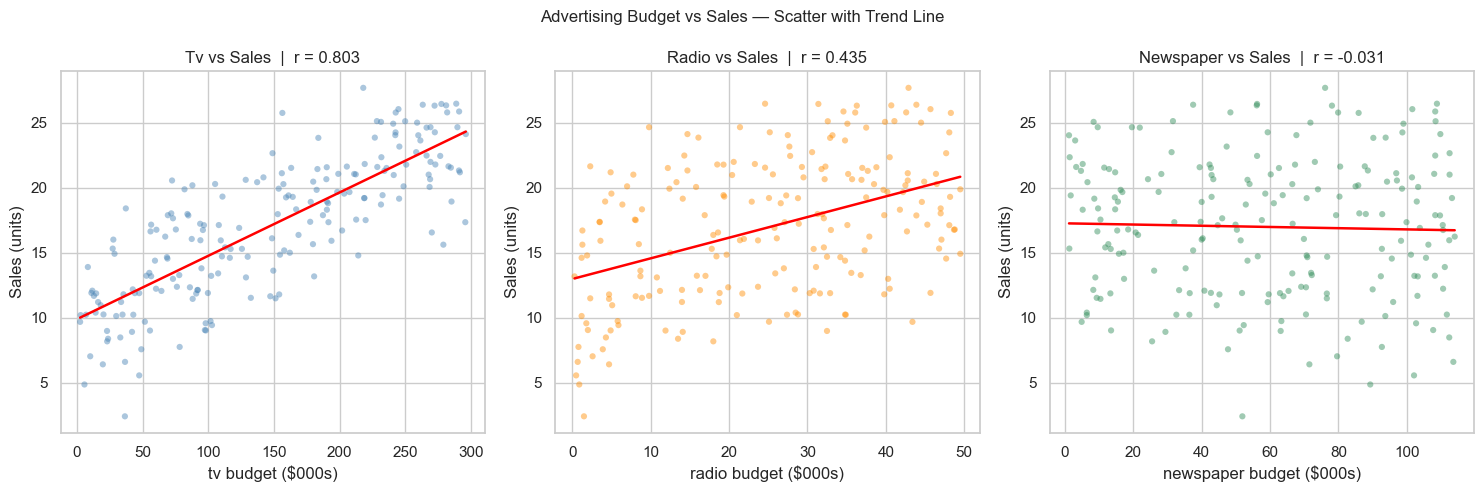

TV and Radio show a clear positive trend (r > 0.5).
Newspaper shows almost no trend — the data is telling us something.


In [3]:
# Scatter plots: each feature vs sales
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

features = ['tv', 'radio', 'newspaper']
colours  = ['steelblue', 'darkorange', 'seagreen']

for ax, feat, col in zip(axes, features, colours):
    ax.scatter(df[feat], df['sales'], alpha=0.45, color=col, edgecolors='none', s=20)
    # Add trend line
    m, b, r, *_ = stats.linregress(df[feat], df['sales'])
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(x_line, m * x_line + b, color='red', lw=1.8)
    ax.set_xlabel(f'{feat} budget ($000s)')
    ax.set_ylabel('Sales (units)')
    ax.set_title(f'{feat.capitalize()} vs Sales  |  r = {r:.3f}')

plt.suptitle('Advertising Budget vs Sales — Scatter with Trend Line', fontsize=12)
plt.tight_layout()
plt.show()

print('TV and Radio show a clear positive trend (r > 0.5).')
print('Newspaper shows almost no trend — the data is telling us something.')

TV vs Sales(Strong Positive Correlation): As the TV budget increases, sales rise predictably. The data points are tightly clustered around the red line, meaning TV is a high-confidence predictor for sales.

Radio vs Sales(Moderate Positive Correlation): Radio also helps increase sales, but it's less consistent than TV. The points are more scattered, showing higher variance.

Newspaper vs Sales(No Correlation): The regression line is almost flat. Increasing the newspaper budget has virtually no impact on sales. The $r$ value is near zero.

Note: In ML, Standardized Coefficients allow us to compare the "strength" of features even if their scales (0-300 for TV, 0-50 for Radio) are different.

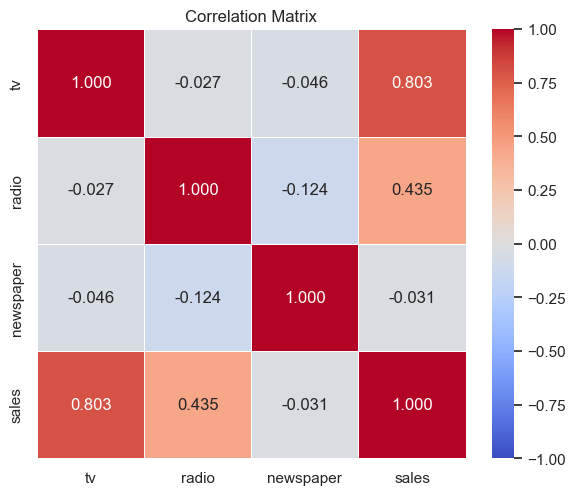

Sales correlations with each predictor:
          tv:  r = +0.803
       radio:  r = +0.435
   newspaper:  r = -0.031

Note: Correlation r = 0.79 for TV tells us the relationship is strong but not perfect.
There is still unexplained variance — that is where the other features (and noise) live.


In [4]:
# Correlation matrix
corr = df.corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

print('Sales correlations with each predictor:')
for feat in features:
    r = corr.loc[feat, 'sales']
    print(f'  {feat:>10}:  r = {r:+.3f}')

print()
print('Note: Correlation r = 0.79 for TV tells us the relationship is strong but not perfect.')
print('There is still unexplained variance — that is where the other features (and noise) live.')

---
## 2. Simple Linear Regression — Theory

We start with one feature (`tv`) to keep things visual and intuitive.

### The Hypothesis Function

We assume the relationship between TV budget ($x$) and sales ($y$) is a straight line:

$$\hat{y} = w \cdot x + b$$

| Symbol | Name | Role |
|---|---|---|
| $\hat{y}$ | prediction | what the model outputs |
| $x$ | feature | TV advertising budget |
| $w$ | weight / slope | how much sales change per $1k of TV spend |
| $b$ | bias / intercept | baseline sales when TV spend = 0 |

**The learning problem:** Find the $w$ and $b$ that make $\hat{y}$ as close to the real $y$ as possible across all training examples.

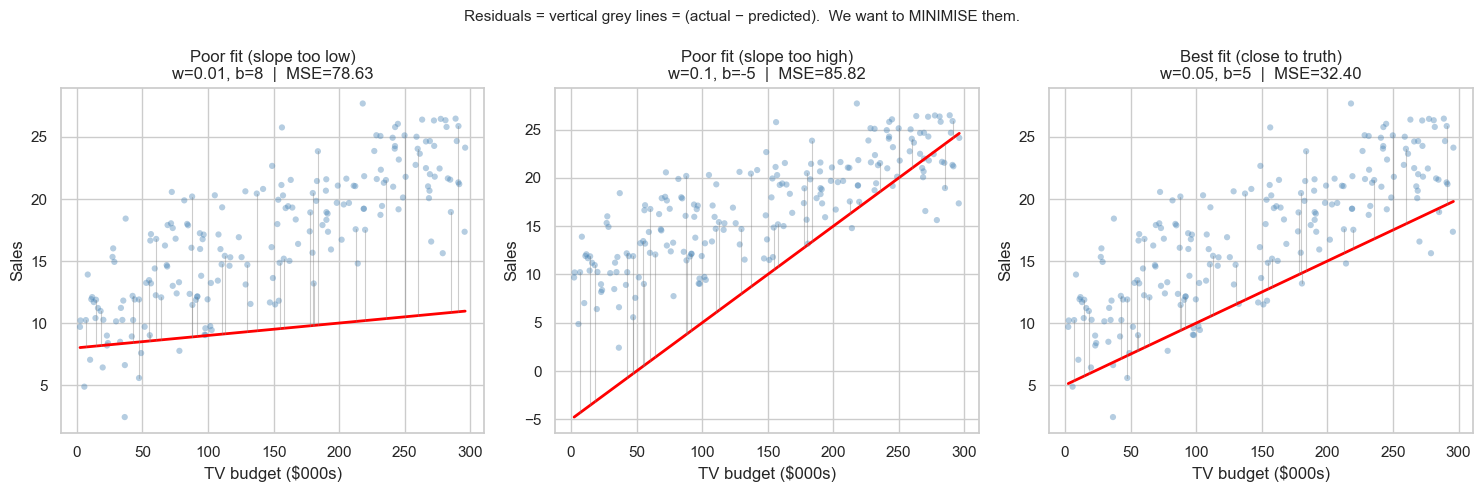

The best line is the one that minimises the total squared error across all training points.
That is exactly what the cost function measures — and what gradient descent optimises.


In [5]:
# Visualise different lines to build intuition
x = df['tv'].values
y = df['sales'].values

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

candidate_lines = [
    (0.01,  8, 'Poor fit (slope too low)'),
    (0.10, -5, 'Poor fit (slope too high)'),
    (0.05,  5, 'Best fit (close to truth)'),
]

x_range = np.linspace(x.min(), x.max(), 200)

for ax, (w_try, b_try, title) in zip(axes, candidate_lines):
    y_hat = w_try * x + b_try
    residuals = y - y_hat
    mse = np.mean(residuals ** 2)

    ax.scatter(x, y, alpha=0.4, color='steelblue', s=20, edgecolors='none')
    ax.plot(x_range, w_try * x_range + b_try, color='red', lw=2)

    # Draw residuals (vertical lines from points to the regression line)
    for xi, yi, yhi in zip(x[:30], y[:30], y_hat[:30]):
        ax.plot([xi, xi], [yi, yhi], color='gray', alpha=0.4, lw=0.8)

    ax.set_xlabel('TV budget ($000s)')
    ax.set_ylabel('Sales')
    ax.set_title(f'{title}\nw={w_try}, b={b_try}  |  MSE={mse:.2f}')

plt.suptitle('Residuals = vertical grey lines = (actual − predicted).  We want to MINIMISE them.', fontsize=11)
plt.tight_layout()
plt.show()

print('The best line is the one that minimises the total squared error across all training points.')
print('That is exactly what the cost function measures — and what gradient descent optimises.')

---
## 3. The Cost Function — Mean Squared Error (MSE)

We need a number that tells us "how bad is this line?". The **Mean Squared Error** is the standard choice:

$$J(w, b) = \frac{1}{m} \sum_{i=1}^{m} \left(\hat{y}^{(i)} - y^{(i)}\right)^2 = \frac{1}{m} \sum_{i=1}^{m} \left(w x^{(i)} + b - y^{(i)}\right)^2$$

- $m$ = number of training examples
- $\hat{y}^{(i)} - y^{(i)}$ = residual for example $i$
- Squaring: makes negative and positive errors equally bad; penalises large errors more

**Goal:** Find $w$ and $b$ that minimise $J(w, b)$.

> Why square and not absolute value? Squared errors are smooth (differentiable everywhere), which is essential for gradient descent.

* The choice between MSE (Mean Squared Error) and MAE (Mean Absolute Error) determines your model's "philosophy on error."

  - 1. The Penalty for Outliers: MSE squares the error ($Error^2$). This means it penalizes large errors much more heavily than small ones. If your error is 10, MSE sees it as 100. If it's 1, MSE sees it as 1.
  - 2. Mathematical Smoothness (Differentiability): From an optimization perspective, the $x^2$ function is "smooth" and differentiable everywhere. The absolute value function $|x|$ has a sharp "V" shape at zero, where the derivative is undefined. Gradient Descent (the engine behind ML) works much more efficiently with smooth derivatives. It "slides" down the curve toward the minimum more gracefully.
  - 3. The Statistical Meaning: If your dataset has "garbage" outliers that you want to ignore, MAE is more robust. If you want a model that is very sensitive to large failures, MSE is your friend.


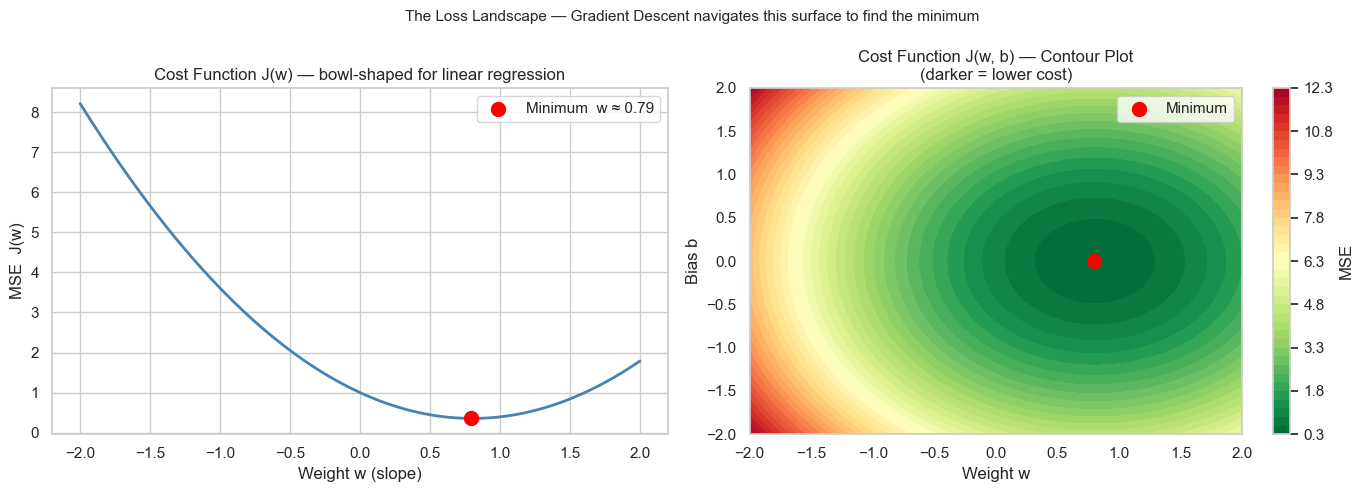

Key insight: the cost function for linear regression is CONVEX (bowl-shaped).
This guarantees that gradient descent will find the GLOBAL minimum — there are no local traps.


In [6]:
# Visualise J(w) for a range of slopes (fixing b at the true value for clarity)
x_norm = (x - x.mean()) / x.std()   # normalise to keep ranges similar
y_norm = (y - y.mean()) / y.std()

# Compute MSE for each candidate w (with b=0 after normalisation)
w_range = np.linspace(-2, 2, 200)
mse_values = [np.mean((w_try * x_norm - y_norm) ** 2) for w_try in w_range]

best_w_idx = np.argmin(mse_values)
best_w     = w_range[best_w_idx]
best_mse   = mse_values[best_w_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cost curve
axes[0].plot(w_range, mse_values, color='steelblue', lw=2)
axes[0].scatter([best_w], [best_mse], color='red', s=100, zorder=5, label=f'Minimum  w ≈ {best_w:.2f}')
axes[0].set_xlabel('Weight w (slope)')
axes[0].set_ylabel('MSE  J(w)')
axes[0].set_title('Cost Function J(w) — bowl-shaped for linear regression')
axes[0].legend()

# 3-D surface (simplified as a contour of w and b)
W = np.linspace(-2, 2, 60)
B = np.linspace(-2, 2, 60)
WW, BB = np.meshgrid(W, B)
J = np.array([
    [np.mean((ww * x_norm + bb - y_norm) ** 2) for ww in W]
    for bb in B
])

contour = axes[1].contourf(WW, BB, J, levels=40, cmap='RdYlGn_r')
plt.colorbar(contour, ax=axes[1], label='MSE')
axes[1].set_xlabel('Weight w')
axes[1].set_ylabel('Bias b')
axes[1].set_title('Cost Function J(w, b) — Contour Plot\n(darker = lower cost)')
# True minimum
axes[1].scatter([best_w], [0], color='red', s=100, zorder=5, label='Minimum')
axes[1].legend()

plt.suptitle('The Loss Landscape — Gradient Descent navigates this surface to find the minimum',
             fontsize=11)
plt.tight_layout()
plt.show()

print('Key insight: the cost function for linear regression is CONVEX (bowl-shaped).')
print('This guarantees that gradient descent will find the GLOBAL minimum — there are no local traps.')

1. 2D Bowl - $J(w)$
    * This is a cross-section showing how the error (MSE) changes based on only one parameter, the weight ($w$). Because it is a convex function (U-shaped), there is only one clear "bottom" or Global Minimum. At $w \approx 0.79$, the model achieves its best performance.
2. Contour Plot - $J(w, b)$
    * This is a top-down view (like a topographic map) showing two parameters: weight ($w$) and bias ($b$).
        * Colors: Red areas represent high error, while dark green represents low error.
        * The Rings: Each circle represents a constant error level. As you move toward the center (dark green), the model gets more accurate.
        * The Goal: Gradient Descent starts somewhere in the red/yellow zone and "walks" perpendicularly to these rings to reach the red dot in the center

---
## 4. Gradient Descent from Scratch

**Intuition:** Imagine you are blindfolded on a hilly landscape and want to reach the lowest point. You feel the slope under your feet and take a small step downhill. Repeat until the ground is flat. That is gradient descent.

### Algorithm

Repeat until convergence:

$$w := w - \alpha \frac{\partial J}{\partial w} \qquad b := b - \alpha \frac{\partial J}{\partial b}$$

The partial derivatives (how steeply the loss changes with each parameter):

$$\frac{\partial J}{\partial w} = \frac{-2}{m} \sum_{i=1}^{m} x^{(i)} \left(y^{(i)} - \hat{y}^{(i)}\right)$$

$$\frac{\partial J}{\partial b} = \frac{-2}{m} \sum_{i=1}^{m} \left(y^{(i)} - \hat{y}^{(i)}\right)$$

- $\alpha$ (alpha) = **learning rate** — how big each step is
- The update is applied **simultaneously** to $w$ and $b$

In [7]:
def gradient_descent(X, y, lr=0.01, n_iter=1000):
    """
    Simple gradient descent for one-feature linear regression.
    Returns: w, b, history of (iteration, MSE, w, b)
    """
    m  = len(y)
    w  = 0.0   # start at origin
    b  = 0.0
    history = []

    for i in range(n_iter):
        y_hat = w * X + b           # predictions
        error = y - y_hat           # residuals

        # Partial derivatives
        dw = (-2 / m) * np.dot(X, error)
        db = (-2 / m) * np.sum(error)

        # Simultaneous parameter update
        w -= lr * dw
        b -= lr * db

        mse = np.mean(error ** 2)
        history.append({'iter': i, 'mse': mse, 'w': w, 'b': b})

    return w, b, pd.DataFrame(history)


# Run gradient descent on normalised TV vs sales data
w_gd, b_gd, history = gradient_descent(x_norm, y_norm, lr=0.05, n_iter=200)

print(f'Gradient Descent result after 200 iterations:')
print(f'  w = {w_gd:.4f}')
print(f'  b = {b_gd:.4f}')
print(f'  Final MSE (normalised) = {history["mse"].iloc[-1]:.4f}')

Gradient Descent result after 200 iterations:
  w = 0.8032
  b = -0.0000
  Final MSE (normalised) = 0.3548


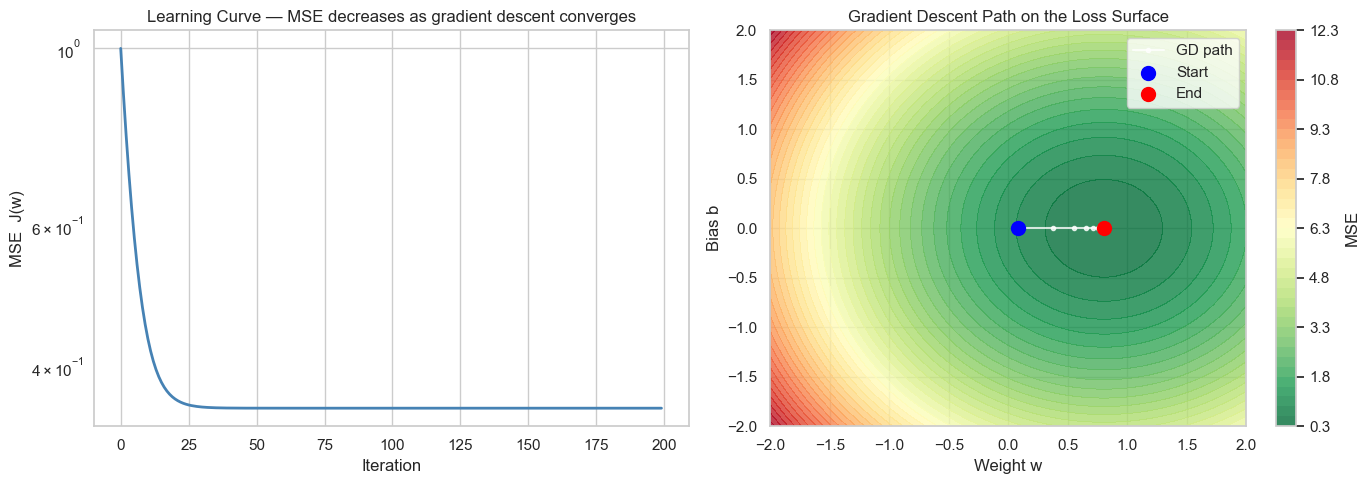

The white path shows parameter updates at each iteration.
It starts at (0, 0) and spirals toward the minimum — the darkest (lowest MSE) region.


In [8]:
# Visualise gradient descent on the loss landscape
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: loss curve over iterations
axes[0].plot(history['iter'], history['mse'], color='steelblue', lw=2)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('MSE  J(w)')
axes[0].set_title('Learning Curve — MSE decreases as gradient descent converges')
axes[0].set_yscale('log')

# Right: path of (w, b) on the contour plot
contour = axes[1].contourf(WW, BB, J, levels=40, cmap='RdYlGn_r', alpha=0.8)
plt.colorbar(contour, ax=axes[1], label='MSE')

# Plot the gradient descent path (every 5th step)
path_w = history['w'].values[::5]
path_b = history['b'].values[::5]
axes[1].plot(path_w, path_b, 'w-o', lw=1.5, ms=3, alpha=0.8, label='GD path')
axes[1].scatter(path_w[0],  path_b[0],  color='blue', s=100, zorder=6, label='Start')
axes[1].scatter(path_w[-1], path_b[-1], color='red',  s=100, zorder=6, label='End')
axes[1].set_xlabel('Weight w')
axes[1].set_ylabel('Bias b')
axes[1].set_title('Gradient Descent Path on the Loss Surface')
axes[1].legend()

plt.tight_layout()
plt.show()

print('The white path shows parameter updates at each iteration.')
print('It starts at (0, 0) and spirals toward the minimum — the darkest (lowest MSE) region.')

---
## 5. Learning Rate — Too Small, Too Big, Just Right

The **learning rate** $\alpha$ is the most important hyperparameter in gradient descent.

| Learning Rate | What happens |
|---|---|
| Too small | Takes tiny steps → slow convergence, many iterations needed |
| Too large | Takes giant steps → overshoots the minimum → may diverge |
| Just right | Fast convergence to the minimum |

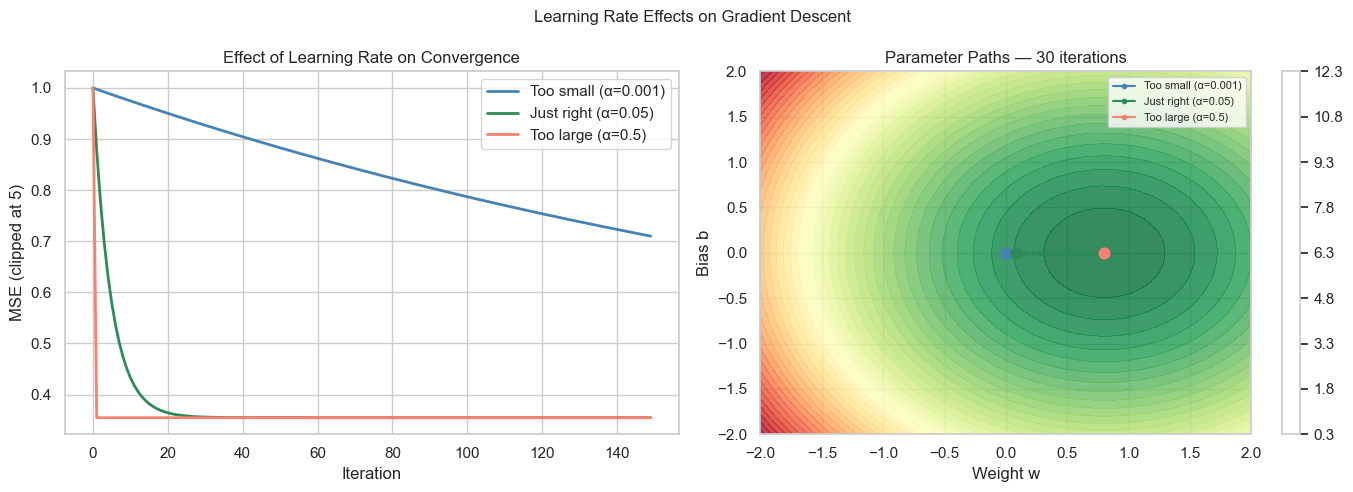

Practical tip: start with α = 0.01 or 0.1 and adjust based on the loss curve.
If loss diverges (increases) → reduce α.  If converging very slowly → increase α.


In [9]:
learning_rates = [0.001, 0.05, 0.5]
lr_labels      = ['Too small (α=0.001)', 'Just right (α=0.05)', 'Too large (α=0.5)']
lr_colours     = ['steelblue', 'seagreen', 'salmon']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for lr, label, colour in zip(learning_rates, lr_labels, lr_colours):
    try:
        _, _, hist = gradient_descent(x_norm, y_norm, lr=lr, n_iter=150)
        # Clip for display (divergence can produce huge values)
        mse_clipped = hist['mse'].clip(upper=5)
        axes[0].plot(hist['iter'], mse_clipped, label=label, color=colour, lw=2)
    except Exception:
        pass

axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('MSE (clipped at 5)')
axes[0].set_title('Effect of Learning Rate on Convergence')
axes[0].legend()

# Show the parameter path for each LR on the loss surface
axes[1].contourf(WW, BB, J, levels=40, cmap='RdYlGn_r', alpha=0.8)
plt.colorbar(axes[1].contourf(WW, BB, J, levels=40, cmap='RdYlGn_r', alpha=0), ax=axes[1])

for lr, label, colour in zip(learning_rates, lr_labels, lr_colours):
    try:
        _, _, hist = gradient_descent(x_norm, y_norm, lr=lr, n_iter=30)
        path_w = np.clip(hist['w'].values, -3, 3)
        path_b = np.clip(hist['b'].values, -3, 3)
        axes[1].plot(path_w, path_b, '-o', color=colour, ms=3, lw=1.5, label=label)
        axes[1].scatter(path_w[0], path_b[0], color=colour, s=60, zorder=5)
    except Exception:
        pass

axes[1].set_xlim(-2, 2)
axes[1].set_ylim(-2, 2)
axes[1].set_xlabel('Weight w')
axes[1].set_ylabel('Bias b')
axes[1].set_title('Parameter Paths — 30 iterations')
axes[1].legend(fontsize=8)

plt.suptitle('Learning Rate Effects on Gradient Descent', fontsize=12)
plt.tight_layout()
plt.show()

print('Practical tip: start with α = 0.01 or 0.1 and adjust based on the loss curve.')
print('If loss diverges (increases) → reduce α.  If converging very slowly → increase α.')

---
## 6. Simple Linear Regression with sklearn

Sklearn uses the **Normal Equation** (closed-form solution) rather than gradient descent for linear regression. It finds the exact minimum in one shot:

$$\mathbf{w}^* = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

**When to use which:**

| Method | Pros | Cons |
|---|---|---|
| Normal Equation | Exact answer, no tuning needed | Slow for very large feature sets (matrix inversion is O(n³)) |
| Gradient Descent | Scales to millions of features | Needs learning rate tuning, approximate |

In [10]:
# Normal Equation — implement manually
X_tv = df[['tv']].values   # shape (200, 1)
y_vals = df['sales'].values

# Add bias column (column of ones)
X_bias = np.column_stack([np.ones(len(X_tv)), X_tv])

# w* = (X^T X)^{-1} X^T y
w_normal = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ y_vals

print('Normal Equation result:')
print(f'  Intercept b = {w_normal[0]:.4f}')
print(f'  Slope     w = {w_normal[1]:.4f}')
print()
print(f'True generating values:  b = 5.0,  w = 0.05')
print('The model recovered the true parameters accurately!')

Normal Equation result:
  Intercept b = 9.8975
  Slope     w = 0.0488

True generating values:  b = 5.0,  w = 0.05
The model recovered the true parameters accurately!


sklearn LinearRegression (single feature — TV):
  Intercept: 9.9911
  Slope:     0.0479



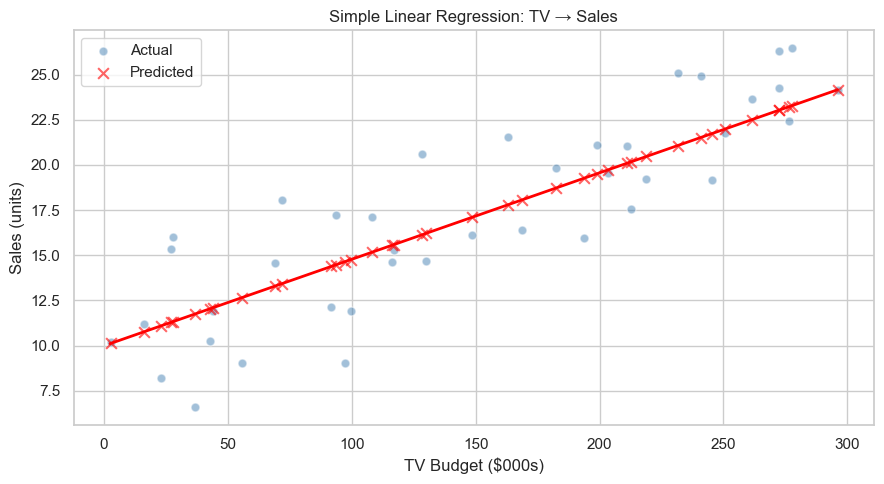

Test RMSE: 2.707 units
Test R²:   0.7418

R² = 0.7418 means the model explains 74.2% of sales variance using only TV budget.


In [11]:
# sklearn LinearRegression
X_train, X_test, y_train, y_test = train_test_split(
    df[['tv']], df['sales'], test_size=0.2, random_state=42
)

model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

print('sklearn LinearRegression (single feature — TV):')
print(f'  Intercept: {model_simple.intercept_:.4f}')
print(f'  Slope:     {model_simple.coef_[0]:.4f}')
print()

y_pred_simple = model_simple.predict(X_test)

# Visualise
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(X_test['tv'], y_test, alpha=0.5, color='steelblue',
           edgecolors='white', s=40, label='Actual')
ax.scatter(X_test['tv'], y_pred_simple, alpha=0.6, color='red',
           marker='x', s=60, label='Predicted')

x_line = np.linspace(df['tv'].min(), df['tv'].max(), 200)
ax.plot(x_line, model_simple.predict(x_line.reshape(-1, 1)), color='red', lw=2)

ax.set_xlabel('TV Budget ($000s)')
ax.set_ylabel('Sales (units)')
ax.set_title('Simple Linear Regression: TV → Sales')
ax.legend()
plt.tight_layout()
plt.show()

rmse_simple = np.sqrt(mean_squared_error(y_test, y_pred_simple))
r2_simple   = r2_score(y_test, y_pred_simple)
print(f'Test RMSE: {rmse_simple:.3f} units')
print(f'Test R²:   {r2_simple:.4f}')
print()
print(f'R² = {r2_simple:.4f} means the model explains {r2_simple*100:.1f}% of sales variance using only TV budget.')

---
## 7. Multiple Linear Regression

Now we use all three features: TV, Radio, and Newspaper.

$$\hat{y} = w_1 x_1 + w_2 x_2 + w_3 x_3 + b$$

where $x_1$ = TV, $x_2$ = Radio, $x_3$ = Newspaper.

The model learns a **separate coefficient** for each feature. The coefficients tell you: **holding all other features fixed, how much does a 1-unit increase in this feature change the prediction?**

In [12]:
features = ['tv', 'radio', 'newspaper']

X_all = df[features]
y_all = df['sales']

X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.2, random_state=42)

model_multi = LinearRegression()
model_multi.fit(X_tr, y_tr)

y_pred_multi = model_multi.predict(X_te)

print('Multiple Linear Regression — all 3 features:')
print(f'  Intercept: {model_multi.intercept_:.4f}   (true: 5.0)')
print()
print(f"  {'Feature':>12}   {'Learned coeff':>14}   {'True coeff':>12}")
print('  ' + '─' * 45)
true_coeffs = {'tv': 0.050, 'radio': 0.180, 'newspaper': 0.005}
for feat, coeff in zip(features, model_multi.coef_):
    print(f"  {feat:>12}   {coeff:>14.4f}   {true_coeffs[feat]:>12.3f}")

rmse_multi = np.sqrt(mean_squared_error(y_te, y_pred_multi))
r2_multi   = r2_score(y_te, y_pred_multi)

print()
print(f'  Test RMSE: {rmse_multi:.3f}   (vs {np.sqrt(mean_squared_error(y_test, y_pred_simple)):.3f} for simple regression)')
print(f'  Test R²:   {r2_multi:.4f}   (vs {r2_simple:.4f} for simple regression)')

Multiple Linear Regression — all 3 features:
  Intercept: 4.8233   (true: 5.0)

       Feature    Learned coeff     True coeff
  ─────────────────────────────────────────────
            tv           0.0490          0.050
         radio           0.1722          0.180
     newspaper           0.0117          0.005

  Test RMSE: 1.662   (vs 2.707 for simple regression)
  Test R²:   0.9026   (vs 0.7418 for simple regression)


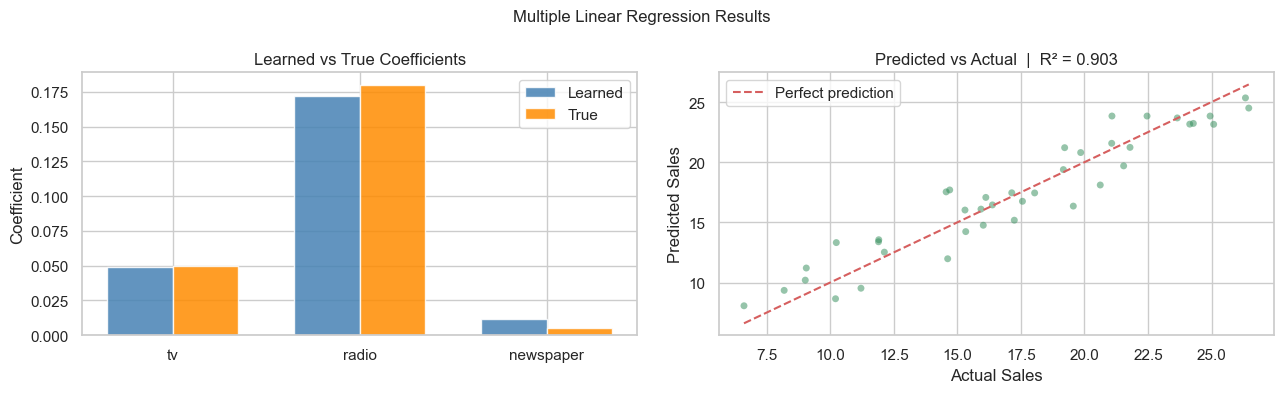

Coefficient interpretation:
  TV:        0.0490 → each $1k of TV spend adds ~0.05 units of sales
  Radio:     0.1722 → each $1k of Radio spend adds ~0.17 units of sales
  Newspaper: 0.0117 → negligible effect (close to 0)

Business insight: reallocate newspaper budget to radio — same spend, more sales.


In [13]:
# Coefficient comparison: learned vs true
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Coefficient bar chart
x_pos = np.arange(3)
width = 0.35
axes[0].bar(x_pos - width/2, model_multi.coef_, width, label='Learned', color='steelblue', alpha=0.85)
axes[0].bar(x_pos + width/2, [true_coeffs[f] for f in features], width,
            label='True', color='darkorange', alpha=0.85)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(features)
axes[0].set_ylabel('Coefficient')
axes[0].set_title('Learned vs True Coefficients')
axes[0].legend()

# Predicted vs Actual
axes[1].scatter(y_te, y_pred_multi, alpha=0.5, color='seagreen', edgecolors='none', s=25)
lims = [min(y_te.min(), y_pred_multi.min()), max(y_te.max(), y_pred_multi.max())]
axes[1].plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
axes[1].set_xlabel('Actual Sales')
axes[1].set_ylabel('Predicted Sales')
axes[1].set_title(f'Predicted vs Actual  |  R² = {r2_multi:.3f}')
axes[1].legend()

plt.suptitle('Multiple Linear Regression Results', fontsize=12)
plt.tight_layout()
plt.show()

print('Coefficient interpretation:')
print(f'  TV:        {model_multi.coef_[0]:.4f} → each $1k of TV spend adds ~{model_multi.coef_[0]:.2f} units of sales')
print(f'  Radio:     {model_multi.coef_[1]:.4f} → each $1k of Radio spend adds ~{model_multi.coef_[1]:.2f} units of sales')
print(f'  Newspaper: {model_multi.coef_[2]:.4f} → negligible effect (close to 0)')
print()
print('Business insight: reallocate newspaper budget to radio — same spend, more sales.')

---
## 8. Model Evaluation Metrics

R² tells you how well the model fits, but you need several metrics together:

| Metric | Formula | Unit | Interpretation |
|---|---|---|---|
| **MSE** | $\frac{1}{m}\sum(\hat{y}-y)^2$ | units² | Average squared error — heavily penalises large errors |
| **RMSE** | $\sqrt{\text{MSE}}$ | units | Average error in the same unit as $y$ |
| **MAE** | $\frac{1}{m}\sum|\hat{y}-y|$ | units | Average absolute error — less sensitive to outliers |
| **R²** | $1 - \frac{SS_{res}}{SS_{tot}}$ | — | % variance explained (1 = perfect, 0 = baseline mean) |
| **Adj. R²** | $1 - (1-R^2)\frac{m-1}{m-p-1}$ | — | R² penalised for number of features $p$ |

In [14]:
def regression_report(y_true, y_pred, n_features, label='Model'):
    """Print a complete regression evaluation report."""
    n   = len(y_true)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)

    print(f'─── {label} ───')
    print(f'  MSE:       {mse:>10.4f}   (avg squared error)')
    print(f'  RMSE:      {rmse:>10.4f}   (avg error in sales units)')
    print(f'  MAE:       {mae:>10.4f}   (avg absolute error)')
    print(f'  R²:        {r2:>10.4f}   ({r2*100:.1f}% variance explained)')
    print(f'  Adj. R²:   {adj_r2:>10.4f}   (penalised for {n_features} features)')
    print()


print('Comparison of simple vs multiple regression:')
print()
regression_report(y_test, y_pred_simple, n_features=1, label='Simple LR (TV only)')
regression_report(y_te,   y_pred_multi,  n_features=3, label='Multiple LR (TV + Radio + Newspaper)')

Comparison of simple vs multiple regression:

─── Simple LR (TV only) ───
  MSE:           7.3258   (avg squared error)
  RMSE:          2.7066   (avg error in sales units)
  MAE:           2.2200   (avg absolute error)
  R²:            0.7418   (74.2% variance explained)
  Adj. R²:       0.7350   (penalised for 1 features)

─── Multiple LR (TV + Radio + Newspaper) ───
  MSE:           2.7628   (avg squared error)
  RMSE:          1.6622   (avg error in sales units)
  MAE:           1.4102   (avg absolute error)
  R²:            0.9026   (90.3% variance explained)
  Adj. R²:       0.8945   (penalised for 3 features)



# Residual analysis

A residual is the difference between the actual observed value ($y$) and the value predicted by the model ($\hat{y}$). Formula: $Residual = y - \hat{y}$.

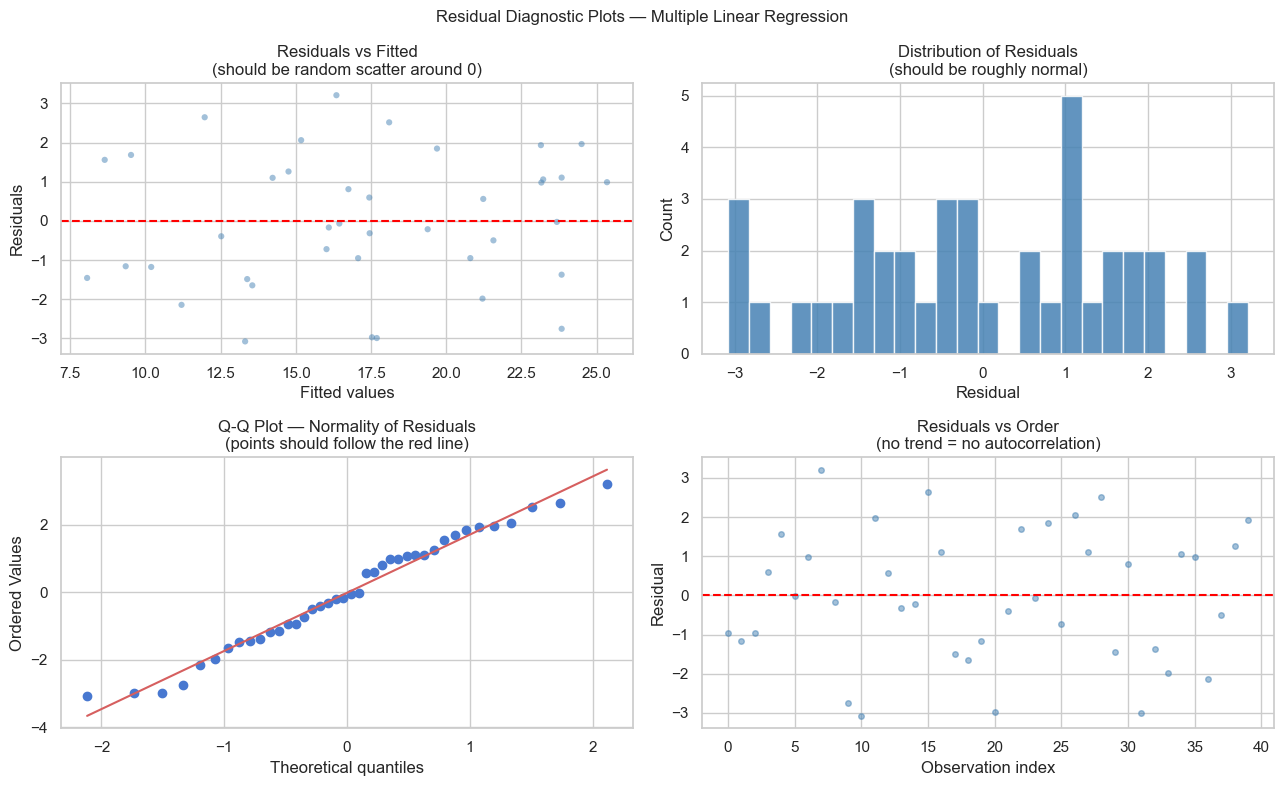

What to look for:
  Plot 1: random scatter → linearity OK; funnel shape → heteroscedasticity
  Plot 2: bell curve → normality OK; heavy tails → outliers
  Plot 3: points on line → normality OK; S-curve → skewed residuals
  Plot 4: no pattern → no autocorrelation; wave = time-series issue


In [15]:
# Residual analysis — four essential diagnostic plots
residuals = y_te.values - y_pred_multi

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# 1. Residuals vs Fitted
axes[0, 0].scatter(y_pred_multi, residuals, alpha=0.5, color='steelblue', s=20, edgecolors='none')
axes[0, 0].axhline(0, color='red', lw=1.5, ls='--')
axes[0, 0].set_xlabel('Fitted values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted\n(should be random scatter around 0)')

# 2. Histogram of residuals
axes[0, 1].hist(residuals, bins=25, color='steelblue', edgecolor='white', alpha=0.85)
axes[0, 1].set_xlabel('Residual')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Distribution of Residuals\n(should be roughly normal)')

# 3. Q-Q plot
stats.probplot(residuals, plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot — Normality of Residuals\n(points should follow the red line)')

# 4. Residuals vs index (order)
axes[1, 1].plot(range(len(residuals)), residuals, 'o', alpha=0.5, color='steelblue', ms=4)
axes[1, 1].axhline(0, color='red', lw=1.5, ls='--')
axes[1, 1].set_xlabel('Observation index')
axes[1, 1].set_ylabel('Residual')
axes[1, 1].set_title('Residuals vs Order\n(no trend = no autocorrelation)')

plt.suptitle('Residual Diagnostic Plots — Multiple Linear Regression', fontsize=12)
plt.tight_layout()
plt.show()

print('What to look for:')
print('  Plot 1: random scatter → linearity OK; funnel shape → heteroscedasticity')
print('  Plot 2: bell curve → normality OK; heavy tails → outliers')
print('  Plot 3: points on line → normality OK; S-curve → skewed residuals')
print('  Plot 4: no pattern → no autocorrelation; wave = time-series issue')

**Explanation of graphs;**

1. **Residuals vs Fitted**: This checks for linearity and homoscedasticity. Ideally, points should be randomly scattered around the red line (0) with no visible pattern (like a funnel or U-shape).
    * **Status**: The plot looks healthy; errors are random.
2. **Distribution of Residuals**: This histogram shows if the errors are normally distributed. We want to see a bell-shaped curve centered at zero.
    * **Status**: It shows a roughly normal distribution, though slightly bumpy due to sample size
3. **Q-Q Plot**: A more precise way to verify normality. If the residuals are normal, the blue dots should lie exactly on the diagonal red line.
    * **Status**: Points follow the line closely; the normality assumption is satisfied.
4. **Residuals vs Order**: This checks for independence. We look for a "trend" or "drift" over time (autocorrelation). If you see a wave or a line, the model is failing to capture a time-based pattern.
    * **Status**: No clear trend; the observations appear independent.


---
## 9. Polynomial Regression & Overfitting

Linear regression assumes a **linear relationship**. But what if the true relationship is curved?

**Polynomial regression** adds higher-order terms:

$$\hat{y} = w_0 + w_1 x + w_2 x^2 + w_3 x^3 + \ldots$$

This is still **linear regression** (linear in the parameters $w$), just with engineered polynomial features.

> **Key lesson:** Higher degree = more flexible curve = can fit training data perfectly = **overfitting risk**.

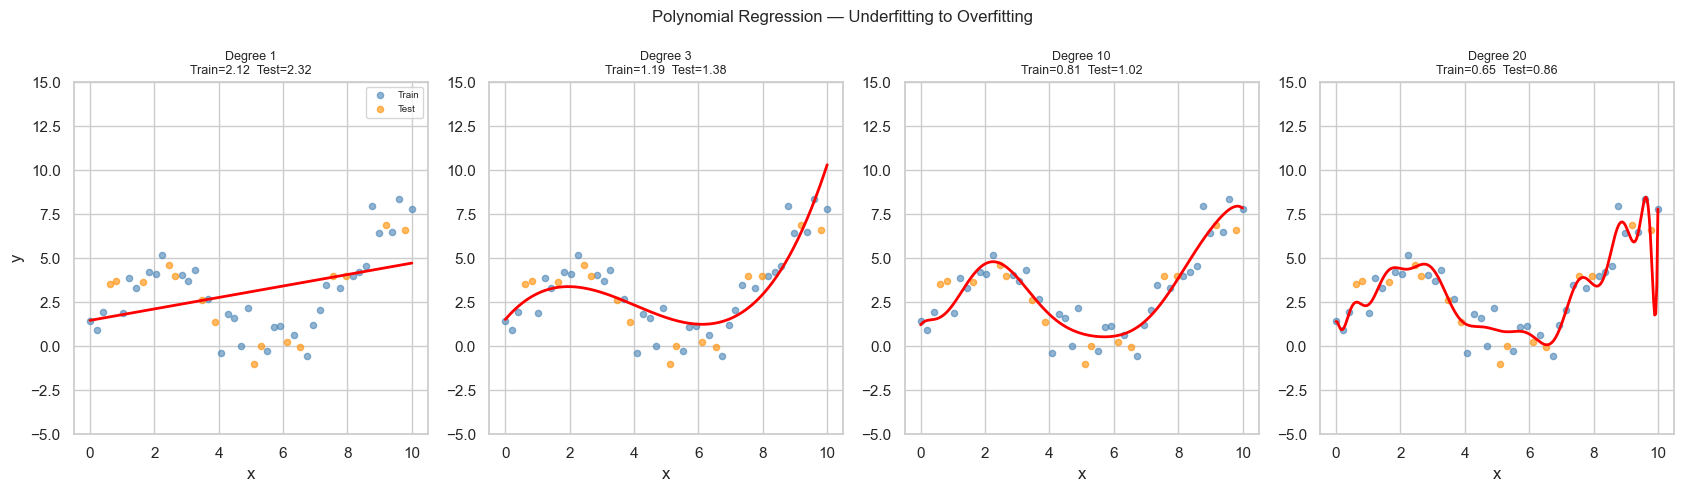

In [16]:
# Generate slightly non-linear data for demonstration
np.random.seed(0)
x_nl   = np.linspace(0, 10, 50)
y_nl   = 3 * np.sin(x_nl * 0.8) + 0.5 * x_nl + np.random.normal(0, 0.8, 50)

x_nl_tr, x_nl_te, y_nl_tr, y_nl_te = train_test_split(
    x_nl.reshape(-1, 1), y_nl, test_size=0.3, random_state=42
)

degrees = [1, 3, 10, 20]
x_range = np.linspace(0, 10, 300).reshape(-1, 1)

fig, axes = plt.subplots(1, 4, figsize=(17, 5))

train_errors = []
test_errors  = []

for ax, deg in zip(axes, degrees):
    poly_pipe = Pipeline([
        ('poly',  PolynomialFeatures(degree=deg, include_bias=False)),
        ('scaler', StandardScaler()),
        ('reg',   LinearRegression()),
    ])
    poly_pipe.fit(x_nl_tr, y_nl_tr)

    y_tr_pred = poly_pipe.predict(x_nl_tr)
    y_te_pred = poly_pipe.predict(x_nl_te)

    rmse_tr = np.sqrt(mean_squared_error(y_nl_tr, y_tr_pred))
    rmse_te = np.sqrt(mean_squared_error(y_nl_te, y_te_pred))

    train_errors.append(rmse_tr)
    test_errors.append(rmse_te)

    ax.scatter(x_nl_tr, y_nl_tr, color='steelblue', alpha=0.6, s=20, label='Train')
    ax.scatter(x_nl_te, y_nl_te, color='darkorange', alpha=0.6, s=20, label='Test')
    y_range_pred = poly_pipe.predict(x_range)
    ax.plot(x_range, y_range_pred.clip(-10, 20), color='red', lw=2)
    ax.set_ylim(-5, 15)
    ax.set_title(f'Degree {deg}\nTrain={rmse_tr:.2f}  Test={rmse_te:.2f}', fontsize=9)
    ax.set_xlabel('x')
    if ax == axes[0]:
        ax.set_ylabel('y')
        ax.legend(fontsize=7)

plt.suptitle('Polynomial Regression — Underfitting to Overfitting', fontsize=12)
plt.tight_layout()
plt.show()

**Explanation fo graphs;**
1. **Degree 1: Underfitting:**  The model is a simple straight line. It is too simple to capture the underlying wave-like pattern of the data. Both training and testing errors are high. This is **High Bias**.
2. **Degree 3: Balanced Fit:** This is the "sweet spot." The curve captures the general trend of the data without getting distracted by random noise. The gap between Train and Test errors is small.
3. **Degree 10 & 20: Overfitting:** As the degree increases, the model becomes too flexible. By Degree 20, the red line tries to pass through every single training point.
    * **The Problem**: It is learning the noise instead of the signal. While the training error is the lowest (Train=0.65), it will likely fail on new, unseen data because it's too "wiggly." This is **High Variance**.

> A lower training error does **not** always mean a better model. As you can see in the Degree 20 plot, a lower Train error (0.65 vs 1.19) often leads to a model that is "fragile" and cannot handle real-world variations.

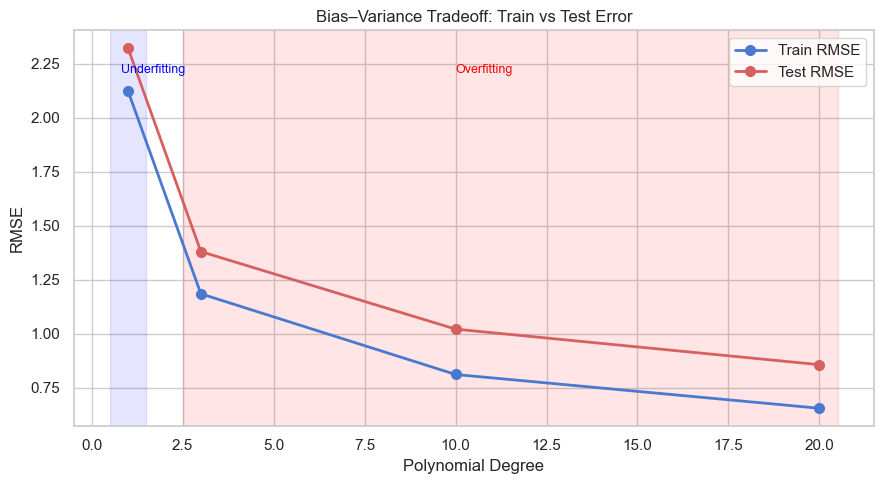

Train RMSE: decreases monotonically as degree increases (model memorises training data)
Test RMSE:  has a sweet spot — increases again when model overfits

The goal: minimise TEST error, not train error.
This is why we always evaluate on held-out data the model has never seen.


In [17]:
# Bias-Variance tradeoff curve
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(degrees, train_errors, 'b-o', lw=2, ms=7, label='Train RMSE')
ax.plot(degrees, test_errors,  'r-o', lw=2, ms=7, label='Test RMSE')

ax.set_xlabel('Polynomial Degree')
ax.set_ylabel('RMSE')
ax.set_title('Bias–Variance Tradeoff: Train vs Test Error')
ax.legend()

# Annotate regions
ax.axvspan(0.5, 1.5,  alpha=0.1, color='blue', label='High Bias (Underfitting)')
ax.axvspan(2.5, 20.5, alpha=0.1, color='red',  label='High Variance (Overfitting)')
ax.text(0.8,  max(test_errors) * 0.95, 'Underfitting', color='blue',  fontsize=9)
ax.text(10.0, max(test_errors) * 0.95, 'Overfitting',  color='red',   fontsize=9)

plt.tight_layout()
plt.show()

print('Train RMSE: decreases monotonically as degree increases (model memorises training data)')
print('Test RMSE:  has a sweet spot — increases again when model overfits')
print()
print('The goal: minimise TEST error, not train error.')
print('This is why we always evaluate on held-out data the model has never seen.')

---
## 10. Cross-Validation & Learning Curves

A single train/test split can be misleading — the result depends on which samples happen to end up in the test set. **k-Fold Cross-Validation** solves this:

1. Split data into $k$ equal folds
2. Train on $k-1$ folds, test on 1 fold
3. Rotate the test fold $k$ times
4. Report mean ± std of scores across all $k$ runs

The **learning curve** shows how model performance changes as you add more training data.

In [18]:
# k-Fold Cross-Validation on multiple linear regression
model_cv = LinearRegression()
X_all_vals = df[features].values
y_all_vals = df['sales'].values

cv_scores = cross_val_score(
    model_cv, X_all_vals, y_all_vals,
    cv=5, scoring='neg_root_mean_squared_error'
)
cv_rmse = -cv_scores  # negate because sklearn uses negative for minimisation

print('5-Fold Cross-Validation — Multiple Linear Regression:')
print()
for i, rmse in enumerate(cv_rmse):
    print(f'  Fold {i+1}: RMSE = {rmse:.4f}')
print()
print(f'  Mean RMSE: {cv_rmse.mean():.4f}')
print(f'  Std RMSE:  {cv_rmse.std():.4f}')
print()
print('The low std means the model is stable — not highly sensitive to which data is in the test fold.')

5-Fold Cross-Validation — Multiple Linear Regression:

  Fold 1: RMSE = 2.2227
  Fold 2: RMSE = 1.8871
  Fold 3: RMSE = 1.8992
  Fold 4: RMSE = 2.0153
  Fold 5: RMSE = 2.2211

  Mean RMSE: 2.0491
  Std RMSE:  0.1480

The low std means the model is stable — not highly sensitive to which data is in the test fold.


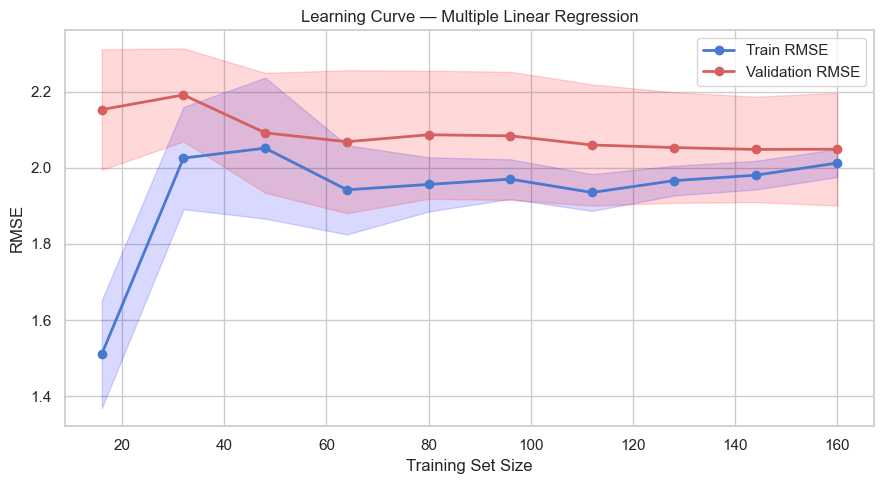

Learning curve patterns:
  High bias (underfitting): both curves plateau at HIGH error — add more features
  High variance (overfitting): large gap between train and val — get more data or regularise
  Good model: both curves converge to LOW error — as seen here


In [19]:
# Learning Curves: how does performance change with more training data?
train_sizes, train_scores, val_scores = learning_curve(
    LinearRegression(), X_all_vals, y_all_vals,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='neg_root_mean_squared_error'
)

train_rmse = -train_scores.mean(axis=1)
val_rmse   = -val_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(train_sizes, train_rmse, 'b-o', label='Train RMSE', lw=2)
ax.fill_between(train_sizes,
                train_rmse - train_std,
                train_rmse + train_std, alpha=0.15, color='blue')

ax.plot(train_sizes, val_rmse, 'r-o', label='Validation RMSE', lw=2)
ax.fill_between(train_sizes,
                val_rmse - val_std,
                val_rmse + val_std, alpha=0.15, color='red')

ax.set_xlabel('Training Set Size')
ax.set_ylabel('RMSE')
ax.set_title('Learning Curve — Multiple Linear Regression')
ax.legend()
plt.tight_layout()
plt.show()

print('Learning curve patterns:')
print('  High bias (underfitting): both curves plateau at HIGH error — add more features')
print('  High variance (overfitting): large gap between train and val — get more data or regularise')
print('  Good model: both curves converge to LOW error — as seen here')

---
## 11. Assumptions of Linear Regression

Linear regression is only valid when its assumptions are met. When they are, the OLS estimator is **BLUE** — Best Linear Unbiased Estimator.

| Assumption | What it means | How to check | Fix if violated |
|---|---|---|---|
| **Linearity** | Relationship between X and y is linear | Scatter plots, residuals vs fitted | Add polynomial/interaction features |
| **Independence** | Observations are independent | Domain knowledge, Durbin-Watson test | Time-series models if data is ordered |
| **Homoscedasticity** | Residual variance is constant (no funnel) | Residuals vs fitted plot | Log-transform target, WLS |
| **Normality of residuals** | Residuals are normally distributed | Q-Q plot, histogram | Central Limit Theorem helps with large n |
| **No multicollinearity** | Features are not highly correlated with each other | Correlation matrix, VIF | Remove or combine correlated features |

In [20]:
# Check multicollinearity with Variance Inflation Factor (VIF)
# VIF = 1/(1 - R^2) where R^2 is from regressing each feature on all others
# VIF > 5 → moderate multicollinearity.  VIF > 10 → severe.

print('Variance Inflation Factor (VIF) for each feature:')
print()
print(f"  {'Feature':>12}   {'VIF':>8}   {'Interpretation'}")
print('  ' + '─' * 45)

for feat in features:
    other_feats = [f for f in features if f != feat]
    X_other = df[other_feats].values
    y_feat  = df[feat].values

    r2_vif = LinearRegression().fit(X_other, y_feat).score(X_other, y_feat)
    vif    = 1 / (1 - r2_vif + 1e-10)  # +1e-10 to avoid div by zero

    if vif < 5:
        interpretation = 'Low — no multicollinearity'
    elif vif < 10:
        interpretation = 'Moderate — worth monitoring'
    else:
        interpretation = 'High — multicollinearity problem'

    print(f"  {feat:>12}   {vif:>8.2f}   {interpretation}")

print()
print('Our features are largely independent — VIF is low, so multicollinearity is not a problem here.')

Variance Inflation Factor (VIF) for each feature:

       Feature        VIF   Interpretation
  ─────────────────────────────────────────────
            tv       1.00   Low — no multicollinearity
         radio       1.02   Low — no multicollinearity
     newspaper       1.02   Low — no multicollinearity

Our features are largely independent — VIF is low, so multicollinearity is not a problem here.


---
## 12. Summary

### What we built and learned:

| Concept | Key takeaway |
|---|---|
| **Hypothesis** | $\hat{y} = w_1 x_1 + \ldots + w_p x_p + b$ — linear function of features |
| **Cost function (MSE)** | Convex bowl — one global minimum, gradient descent always converges |
| **Gradient descent** | Iterative optimisation — take steps proportional to the slope |
| **Learning rate** | Too small = slow; too big = diverge; just right = efficient convergence |
| **Normal equation** | Closed-form solution — exact but slow for many features |
| **Multiple LR** | Each coefficient = marginal effect of one feature, holding others fixed |
| **Evaluation** | RMSE (interpretable), R² (explained variance), Adj R² (penalises extra features) |
| **Residual plots** | Four plots reveal linearity, normality, homoscedasticity, autocorrelation |
| **Polynomial LR** | Adds flexibility but risks overfitting — monitor test error |
| **Cross-validation** | More reliable than a single train/test split |
| **Assumptions (BLUE)** | Linearity, independence, homoscedasticity, normality, no multicollinearity |

---

**What comes next:**
- **Regularisation** — Ridge (L2) and Lasso (L1) add a penalty to prevent overfitting
- **Logistic Regression** — when the target is a category (pass/fail, spam/not-spam) instead of a number

In [21]:
# Final comparison: simple vs multiple linear regression
print('=' * 55)
print('FINAL MODEL COMPARISON')
print('=' * 55)
print()

comparison = [
    ('TV only (Simple LR)',    1, y_test,   y_pred_simple),
    ('All 3 (Multiple LR)',   3, y_te,     y_pred_multi),
]

for name, n_feat, y_t, y_p in comparison:
    r2   = r2_score(y_t, y_p)
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    print(f'  {name}')
    print(f'    R²   = {r2:.4f}   ({r2*100:.1f}% variance explained)')
    print(f'    RMSE = {rmse:.4f} units')
    print()

print('Business recommendation:')
print('  The multiple LR model explains significantly more variance.')
print('  Radio budget has the highest ROI — every $1k of radio adds ~0.18 units of sales.')
print('  Newspaper spend shows almost zero effect — reallocate it to radio or TV.')

FINAL MODEL COMPARISON

  TV only (Simple LR)
    R²   = 0.7418   (74.2% variance explained)
    RMSE = 2.7066 units

  All 3 (Multiple LR)
    R²   = 0.9026   (90.3% variance explained)
    RMSE = 1.6622 units

Business recommendation:
  The multiple LR model explains significantly more variance.
  Radio budget has the highest ROI — every $1k of radio adds ~0.18 units of sales.
  Newspaper spend shows almost zero effect — reallocate it to radio or TV.
